In [152]:
from sklearn.datasets import load_wine

dataset = load_wine()
x = dataset.data
y = dataset.target

print(dataset.feature_names)
print(dataset.target_names)

x = dataset.data
x_cols = dataset.feature_names

y = dataset.target
y_col = dataset.target_names

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


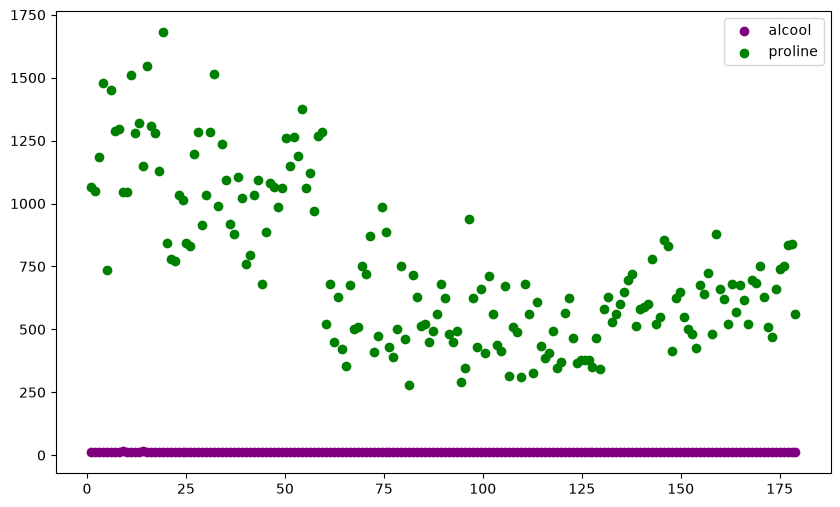

In [153]:
import matplotlib.pylab as plt
import numpy as np
import pandas as pd
df = pd.DataFrame(data=x, columns=x_cols)
samples = np.linspace(1, 179, 178)

plt.figure(figsize=(10, 6))
plt.scatter(x=samples, y=df["alcohol"], label="alcool", color="purple")
plt.scatter(x=samples, y=df["proline"], label="proline", color="green")
plt.legend()
plt.show()


In [154]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

scaler = StandardScaler()

x_train_normalizado = scaler.fit_transform(X_train)
x_test_normalizado = scaler.transform(X_test)

In [155]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(x_train_normalizado)
X_test_pca = pca.transform(x_test_normalizado)

print(pca.explained_variance_ratio_)

[0.35900066 0.18691934]


In [156]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors= 5)
model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)

In [157]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

print(confusion_matrix(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))
print(accuracy_score(y_test, y_pred))

[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
1.0
1.0


In [158]:
import matplotlib.pylab as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import seaborn as sns

def heat_map(dataset, y_test, y_pred):
    cm = confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=dataset.target_names,
        yticklabels=dataset.target_names
    )

    plt.show()

def model_with_pca (dataset, model, n_componetPCA):
    x = dataset.data
    y = dataset.target
    X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

    scaler = StandardScaler()

    
    x_train_normalizado = scaler.fit_transform(X_train)
    x_test_normalizado = scaler.transform(X_test)
    
    pca = PCA(n_components=n_componetPCA)

    X_train_pca = pca.fit_transform(x_train_normalizado)
    X_test_pca = pca.transform(x_test_normalizado)
    
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    f1 = f1_score(y_test, y_pred, average='macro') * 100
    acc = accuracy_score(y_test, y_pred) * 100
    heat_map(dataset, y_test=y_test, y_pred=y_pred)
    print(f"F1-Score: {f1:.2f}%")
    print(f"Acurácia: {acc:.2f}%")

import matplotlib.pylab as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import seaborn as sns


def model_without_pca(dataset, model):
    x = dataset.data
    y = dataset.target
    X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

    scaler = StandardScaler()

    
    x_train_normalizado = scaler.fit_transform(X_train)
    x_test_normalizado = scaler.transform(X_test)
    
    
    model.fit(x_train_normalizado, y_train)
    y_pred = model.predict(x_test_normalizado)
    f1 = f1_score(y_test, y_pred, average='macro') * 100
    acc = accuracy_score(y_test, y_pred) * 100
    heat_map(dataset, y_test=y_test, y_pred=y_pred)
    print(f"F1-Score: {f1:.2f}%")
    print(f"Acurácia: {acc:.2f}%")


In [167]:
import matplotlib.pylab as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA


def heat_map(dataset, y_test, y_pred):

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=dataset.target_names,
        yticklabels=dataset.target_names
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")

    plt.show()


def model_with_pca_with_crossvalidation(
    dataset,
    model,
    n_componetPCA
):

    x = dataset.data
    y = dataset.target

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    f1_scores = []
    accuracies = []

    # Guarda as previsões do último fold
    ultimo_y_test = None
    ultimo_y_pred = None

    for fold, (train_index, test_index) in enumerate(
        skf.split(x, y), 1
    ):

        X_train = x[train_index]
        X_test = x[test_index]

        y_train = y[train_index]
        y_test = y[test_index]

        # -------------------------
        # NORMALIZAÇÃO
        # -------------------------

        scaler = StandardScaler()

        X_train_normalizado = scaler.fit_transform(X_train)
        X_test_normalizado = scaler.transform(X_test)

        # -------------------------
        # PCA
        # -------------------------

        pca = PCA(
            n_components=n_componetPCA
        )

        X_train_pca = pca.fit_transform(
            X_train_normalizado
        )

        X_test_pca = pca.transform(
            X_test_normalizado
        )


        model.fit(
            X_train_pca,
            y_train
        )

        y_pred = model.predict(
            X_test_pca
        )


        f1 = f1_score(
            y_test,
            y_pred,
            average="macro"
        ) * 100

        acc = accuracy_score(
            y_test,
            y_pred
        ) * 100

        f1_scores.append(f1)
        accuracies.append(acc)

        ultimo_y_test = y_test
        ultimo_y_pred = y_pred


    heat_map(
        dataset=dataset,
        y_test=ultimo_y_test,
        y_pred=ultimo_y_pred
    )


    print("\n-----------------------------")

    print(
        f"F1 médio: "
        f"{np.mean(f1_scores):.2f}%"
    )


    print(
        f"Accuracy média: "
        f"{np.mean(accuracies):.2f}%"
    )


def model_without_pca_with_crossvalidation(
    dataset,
    model
):

    x = dataset.data
    y = dataset.target

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    f1_scores = []
    accuracies = []

    ultimo_y_test = None
    ultimo_y_pred = None

    for fold, (train_index, test_index) in enumerate(
        skf.split(x, y), 1
    ):

        X_train = x[train_index]
        X_test = x[test_index]

        y_train = y[train_index]
        y_test = y[test_index]


        scaler = StandardScaler()

        X_train_normalizado = scaler.fit_transform(
            X_train
        )

        X_test_normalizado = scaler.transform(
            X_test
        )


        model.fit(
            X_train_normalizado,
            y_train
        )

        y_pred = model.predict(
            X_test_normalizado
        )


        f1 = f1_score(
            y_test,
            y_pred,
            average="macro"
        ) * 100

        acc = accuracy_score(
            y_test,
            y_pred
        ) * 100

        
        f1_scores.append(f1)
        accuracies.append(acc)

        ultimo_y_test = y_test
        ultimo_y_pred = y_pred



    heat_map(
        dataset=dataset,
        y_test=ultimo_y_test,
        y_pred=ultimo_y_pred
    )


    print("\n-----------------------------")

    print(
        f"F1 médio: "
        f"{np.mean(f1_scores):.2f}%"
    )


    print(
        f"Accuracy média: "
        f"{np.mean(accuracies):.2f}%"
    )

COM PCA


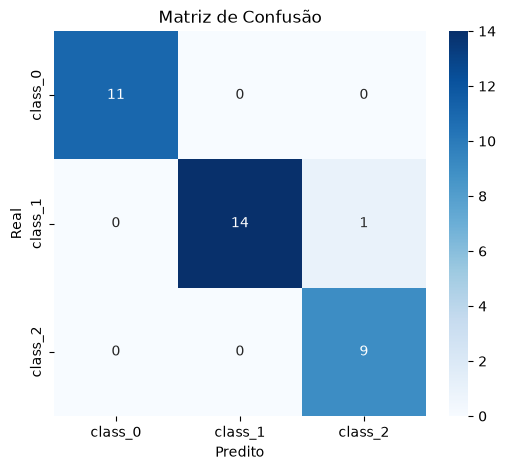


-----------------------------
F1 médio: 97.16%
Accuracy média: 97.19%
----------------------------------------------------
SEM PCA


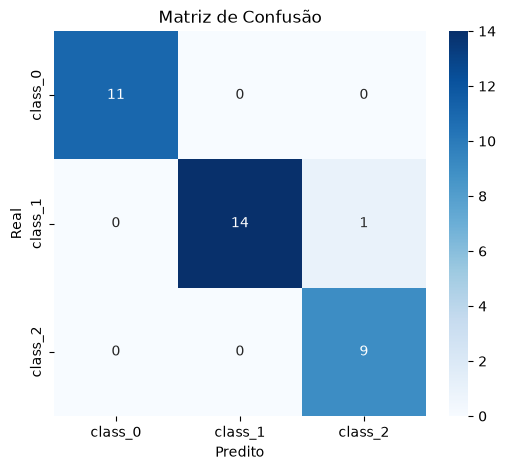


-----------------------------
F1 médio: 97.21%
Accuracy média: 97.17%


In [169]:
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier

dataset = load_wine()
model = KNeighborsClassifier(n_neighbors= 5)

print("COM PCA")
model_with_pca_with_crossvalidation(dataset=dataset,model=model, n_componetPCA=5)
print("----------------------------------------------------")
print("SEM PCA")
model_without_pca_with_crossvalidation(dataset=dataset,model=model)

COM PCA


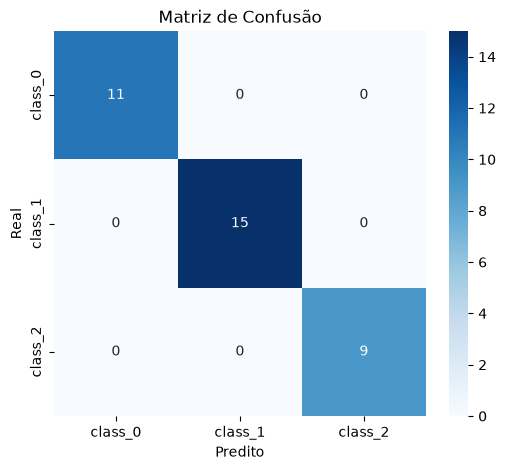


-----------------------------
F1 médio: 97.82%
Accuracy média: 97.78%
----------------------------------------------------
SEM PCA


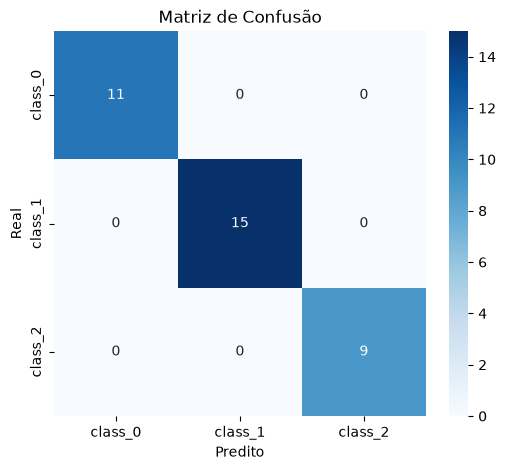


-----------------------------
F1 médio: 97.84%
Accuracy média: 97.75%


In [186]:
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier

dataset = load_wine()
model = RandomForestClassifier(random_state=42)

print("COM PCA")
model_with_pca_with_crossvalidation(dataset=dataset,model=model, n_componetPCA=5)
print("----------------------------------------------------")
print("SEM PCA")
model_without_pca_with_crossvalidation(dataset=dataset,model=model)

Quando você remove colunas do dataset você pode estar removendo informações ruído, melhorando assim a acurácia do modelo 

COM PCA


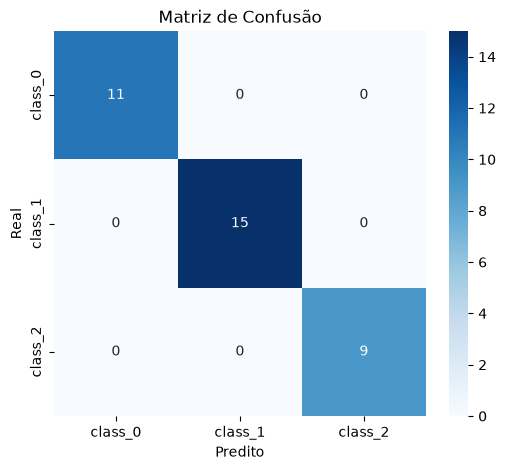


-----------------------------
F1 médio: 97.83%
Accuracy média: 97.76%
----------------------------------------------------
SEM PCA


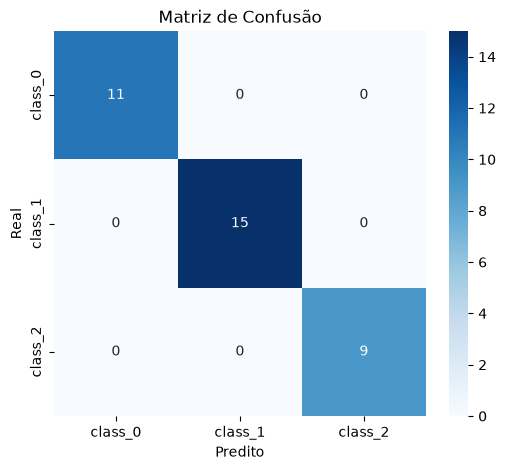


-----------------------------
F1 médio: 98.29%
Accuracy média: 98.33%


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine
model = LogisticRegression(max_iter=100000)

dataset = load_wine()
print("COM PCA")
model_with_pca_with_crossvalidation(dataset=dataset,model=model, n_componetPCA=7)
print("----------------------------------------------------")
print("SEM PCA")
model_without_pca_with_crossvalidation(dataset=dataset,model=model)